## 1. Environment Setup
First, let's install the official Ultralytics library along with OpenCV and Matplotlib, and verify our PyTorch configuration to ensure training uses GPU acceleration.

In [1]:
# Install the required packages
!pip install -q ultralytics opencv-python matplotlib pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 638.1 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 57.7 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 req

In [2]:
import torch
import ultralytics

# Verify ultralytics installation and GPU availability
ultralytics.checks()

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA (GPU) available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Active GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: GPU not available. Training on CPU will be extremely slow. Please enable GPU acceleration if possible (e.g., in Google Colab or local CUDA setup).")

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7035.7/8062.4 GB disk)
PyTorch version: 2.10.0+cu128
CUDA (GPU) available: True
Active GPU Device: Tesla T4


## 2. Dataset Configuration & Inspection
Let's configure the dataset for **single-class pest detection**. Since our dataset originally has 12 pest species (Ants, Bees, Beetles, etc.), we need to:
1. Copy dataset to a writable location (Kaggle's `/kaggle/input/` is read-only)
2. Remap all class IDs in the label files to `0` (merge all species into one `pest` class)
3. Create a new `data.yaml` with `nc: 1` and `names: ["pest"]`

Then we'll visualize some training images with their bounding boxes to verify everything is correct.

In [3]:
import os
import yaml
import glob
import shutil

# === Configuration ===
# YOLO is used as a one-class pest detector.
# All pest species (Ants, Bees, Beetles, etc.) are merged into a single "pest" class.

# Defaults for local execution
data_yaml_path = "dataset/data.yaml"
dataset_root = "dataset"

# Kaggle Environment Detection & Routing
# IMPORTANT: /kaggle/input/ is READ-ONLY on Kaggle!
# We must copy the dataset to /kaggle/working/ before modifying labels.
kaggle_input_dir = "/kaggle/input"
kaggle_working_dir = "/kaggle/working"

if os.path.exists(kaggle_input_dir):
    print("Running on Kaggle! Scanning for a pest dataset directory...")
    detected_path = None

    # Walk /kaggle/input to find where 'train/images' is located.
    for root, dirs, files in os.walk(kaggle_input_dir):
        if "train" in dirs and os.path.exists(os.path.join(root, "train", "images")):
            detected_path = root.replace("\\", "/")
            break

    if detected_path:
        print(f"-> Detected dataset at (read-only): {detected_path}")

        # Copy dataset to writable /kaggle/working/dataset/
        writable_dataset = os.path.join(kaggle_working_dir, "dataset")
        if not os.path.exists(writable_dataset):
            print(f"-> Copying dataset to writable location: {writable_dataset} ...")
            print("   (This may take a few minutes for large datasets)")
            shutil.copytree(detected_path, writable_dataset)
            print(f"-> Copy complete!")
        else:
            print(f"-> Writable dataset already exists at: {writable_dataset}")

        dataset_root = writable_dataset
        print(f"-> Using writable dataset root: {dataset_root}")
    else:
        print("WARNING: Could not find directory containing 'train/images' in /kaggle/input.")
        print("Falling back to local configuration.")
else:
    print("Running in Local environment.")

print(f"\nDataset root: {dataset_root}")

Running on Kaggle! Scanning for a pest dataset directory...
-> Detected dataset at (read-only): /kaggle/input/datasets/rupankarmajumdar/crop-pests-dataset
-> Copying dataset to writable location: /kaggle/working/dataset ...
   (This may take a few minutes for large datasets)
-> Copy complete!
-> Using writable dataset root: /kaggle/working/dataset

Dataset root: /kaggle/working/dataset


In [4]:
# --- Remap all label class IDs to 0 (merge all species into "pest") ---
print("=== Remapping all class IDs to 0 (single-class pest detection) ===")
remapped_count = 0
total_files = 0
for split in ["train", "valid", "test"]:
    lbl_dir = os.path.join(dataset_root, split, "labels")
    if not os.path.exists(lbl_dir):
        print(f"  [SKIP] {lbl_dir} not found")
        continue
    label_files = glob.glob(os.path.join(lbl_dir, "*.txt"))
    total_files += len(label_files)
    for lbl_path in label_files:
        modified = False
        new_lines = []
        with open(lbl_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5 and parts[0] != "0":
                    parts[0] = "0"  # Remap to class 0
                    modified = True
                new_lines.append(" ".join(parts))
        if modified:
            with open(lbl_path, "w") as f:
                f.write("\n".join(new_lines) + "\n")
            remapped_count += 1
print(f"  Total label files scanned: {total_files}")
print(f"  Remapped {remapped_count} label files (others were already class 0).")

# --- Create a one-class YOLO pest detection config ---
pest_yaml_config = {
    "path": os.path.abspath(dataset_root),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 1,
    "names": ["pest"],
}

# Write config to writable location
if os.path.exists(kaggle_working_dir):
    data_yaml_path = os.path.join(kaggle_working_dir, "data.yaml")
else:
    data_yaml_path = os.path.join(dataset_root, "data_pest.yaml")

with open(data_yaml_path, "w") as f:
    yaml.safe_dump(pest_yaml_config, f)
print(f"\n-> Created one-class pest config at: {data_yaml_path}")

# Load and display active configuration
with open(data_yaml_path, "r") as f:
    active_config = yaml.safe_load(f)

print("\n=== Active YOLO Pest Detection Configuration ===")
print(yaml.dump(active_config))

=== Remapping all class IDs to 0 (single-class pest detection) ===
  Total label files scanned: 13143
  Remapped 11962 label files (others were already class 0).

-> Created one-class pest config at: /kaggle/working/data.yaml

=== Active YOLO Pest Detection Configuration ===
names:
- pest
nc: 1
path: /kaggle/working/dataset
test: test/images
train: train/images
val: valid/images



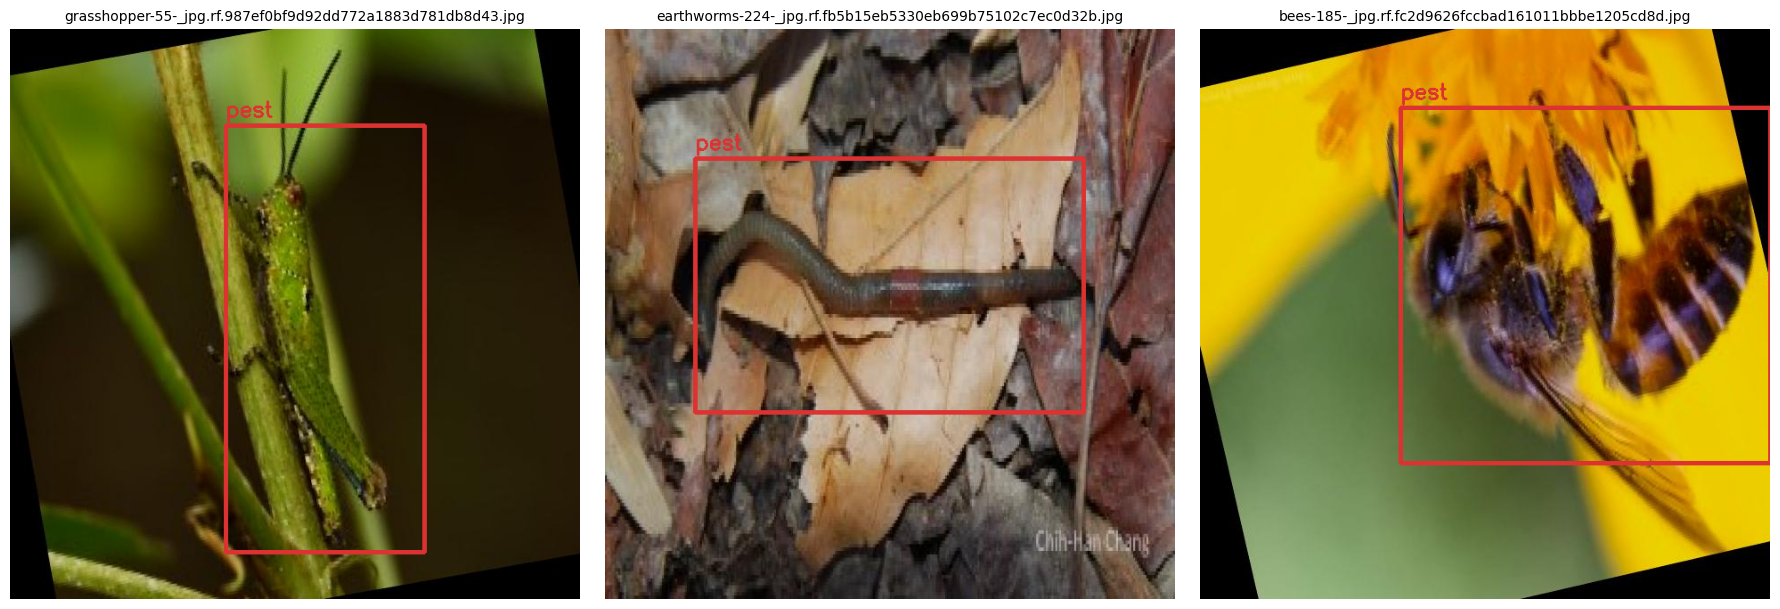

In [5]:
import cv2
import random
import matplotlib.pyplot as plt

def visualize_dataset_samples(split="train", num_samples=3):
    # Resolve dynamic directories
    img_dir = os.path.join(dataset_root, split, "images").replace("\\", "/")
    lbl_dir = os.path.join(dataset_root, split, "labels").replace("\\", "/")
    
    if not os.path.exists(img_dir):
        print(f"Directory {img_dir} does not exist.")
        return
        
    image_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not image_files:
        print(f"No images found in {img_dir}")
        return
        
    selected_images = random.sample(image_files, min(num_samples, len(image_files)))
    fig, axes = plt.subplots(1, len(selected_images), figsize=(18, 6))
    
    if len(selected_images) == 1:
        axes = [axes]
        
    for ax, img_name in zip(axes, selected_images):
        img_path = os.path.join(img_dir, img_name)
        lbl_name = os.path.splitext(img_name)[0] + ".txt"
        lbl_path = os.path.join(lbl_dir, lbl_name)
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        
        if os.path.exists(lbl_path):
            with open(lbl_path, "r") as f:
                lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    # BBox: class_id, x_center, y_center, width, height
                    x_c, y_c, bw, bh = map(float, parts[1:])
                    
                    # Convert normalized coordinates to absolute pixels
                    x1 = int((x_c - bw / 2.0) * w)
                    y1 = int((y_c - bh / 2.0) * h)
                    x2 = int((x_c + bw / 2.0) * w)
                    y2 = int((y_c + bh / 2.0) * h)
                    
                    # Draw bounding box and label
                    cv2.rectangle(img, (x1, y1), (x2, y2), (220, 50, 50), 3)
                    cv2.putText(img, "pest", (x1, max(15, y1 - 10)), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (220, 50, 50), 2)
        
        ax.imshow(img)
        ax.set_title(img_name, fontsize=10)
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()

# Visualizing samples from the training set
visualize_dataset_samples(split="train", num_samples=3)

## 3. Model Training
Now let's train a YOLOv11 model on our single-class pest detection dataset. We use the `yolo11n.pt` pretrained weights as a starting point for transfer learning.

In [6]:
from ultralytics import YOLO

# Load a pretrained YOLOv11 nano model
model = YOLO("yolo11n.pt")

# Train the model on our pest detection dataset
results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    name="yolo11_pest_detector",
    verbose=True,
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_pest_detector, nbs=64, nms=Fa

## 4. Training Results & Metrics
Let's visualize the training metrics and evaluate the model's performance on the validation set.

Training results saved to: /kaggle/working/runs/detect/yolo11_pest_detector


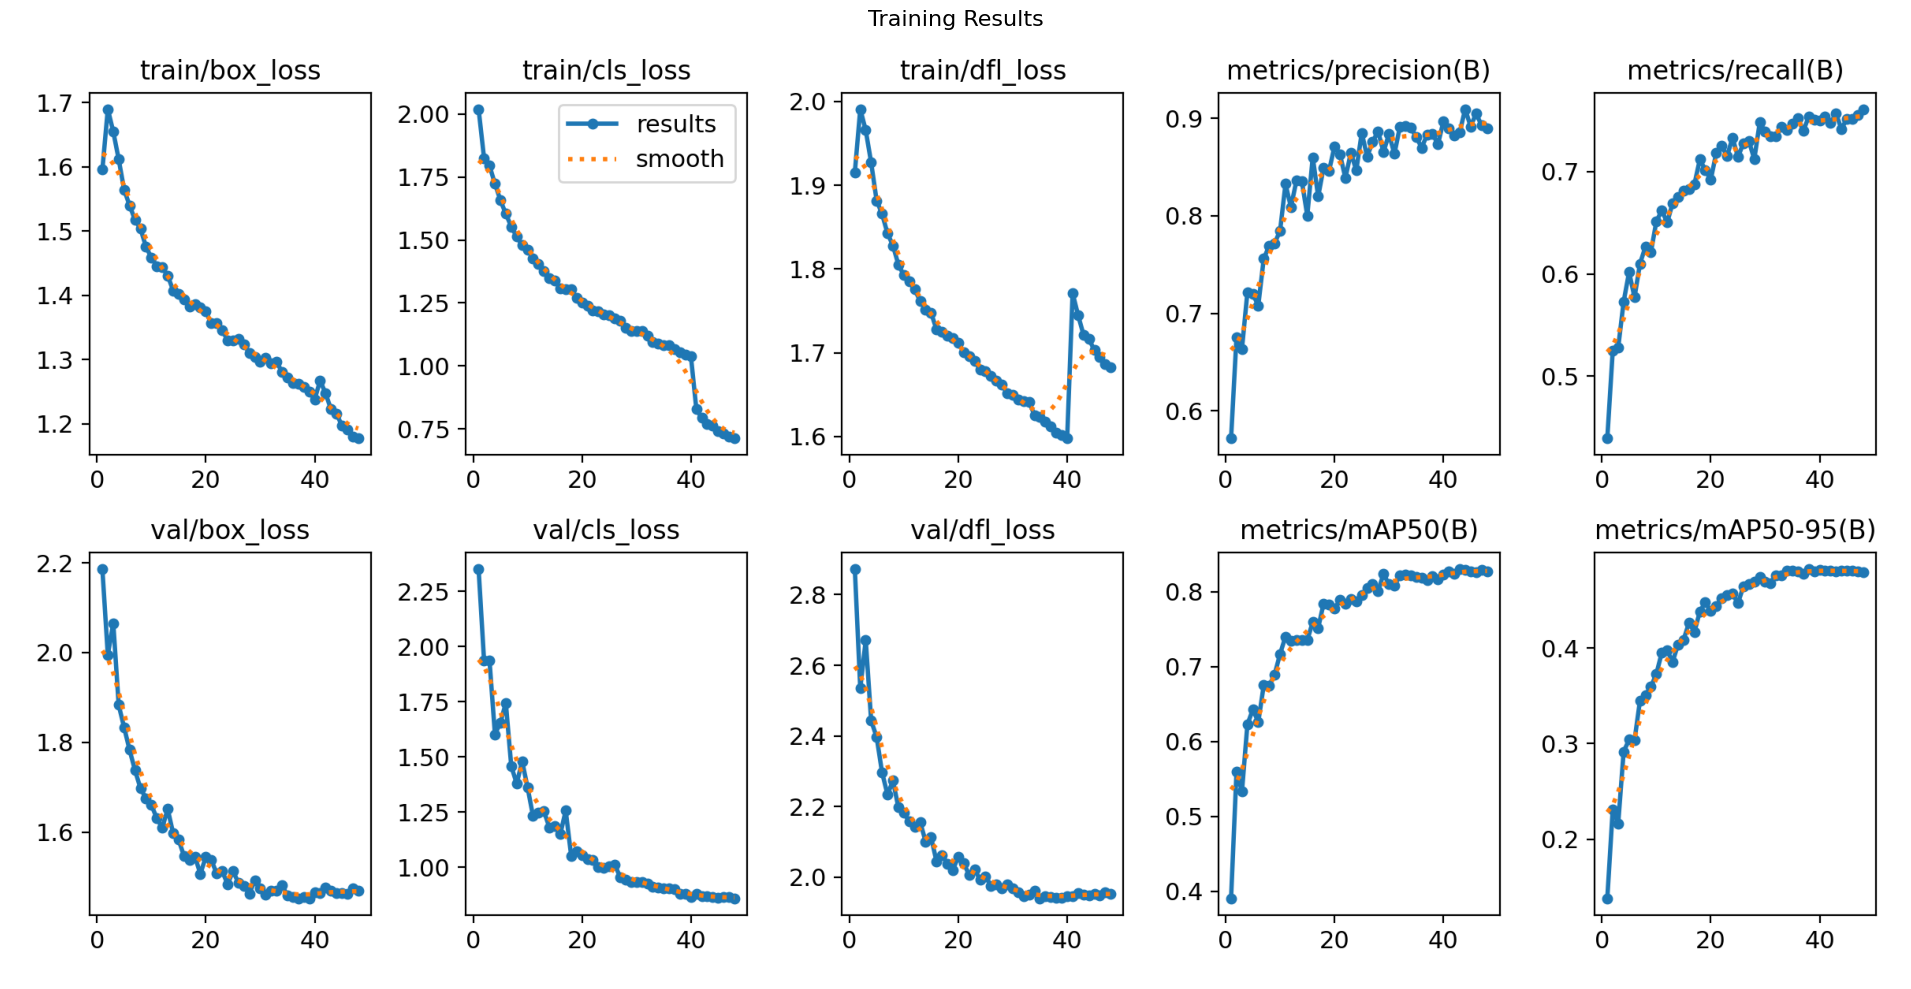

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Find the latest training run directory
run_dir = results.save_dir if hasattr(results, 'save_dir') else "runs/detect/yolo11_pest_detector"
print(f"Training results saved to: {run_dir}")

# Display training curves
results_img_path = os.path.join(str(run_dir), "results.png")
if os.path.exists(results_img_path):
    img = mpimg.imread(results_img_path)
    fig, ax = plt.subplots(1, 1, figsize=(20, 10))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Training Results", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print(f"Results image not found at: {results_img_path}")

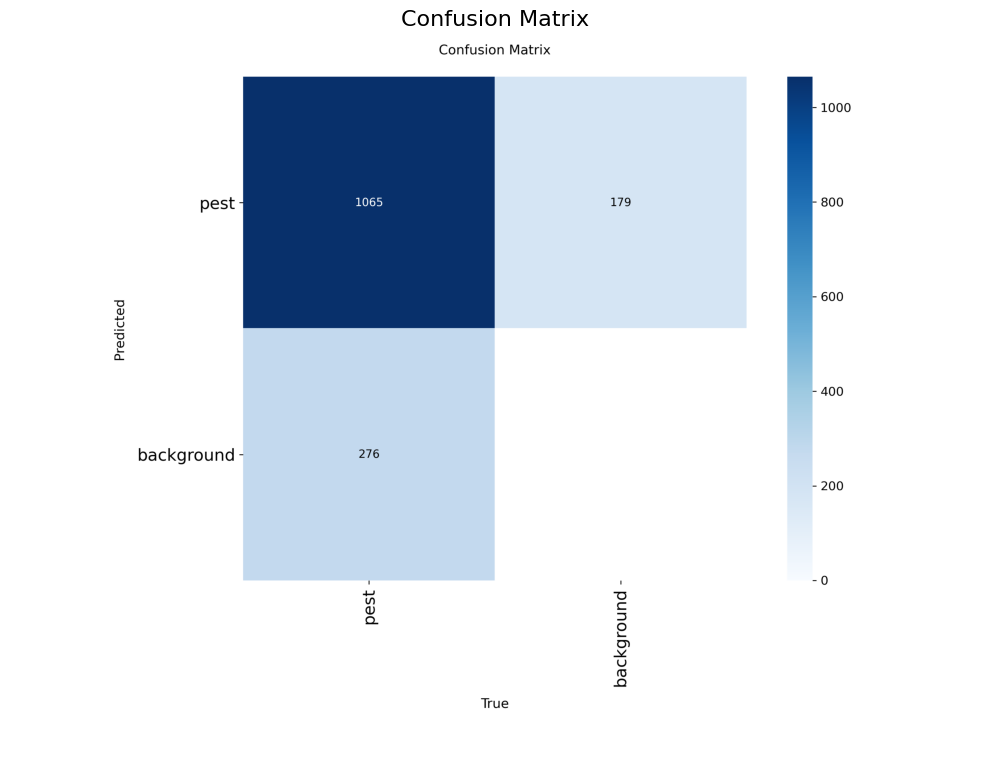

In [8]:
# Display confusion matrix
confusion_matrix_path = os.path.join(str(run_dir), "confusion_matrix.png")
if os.path.exists(confusion_matrix_path):
    img = mpimg.imread(confusion_matrix_path)
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Confusion Matrix", fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print(f"Confusion matrix not found at: {confusion_matrix_path}")

## 5. Validation & Testing
Run the model on the validation and test sets to get final metrics.

In [9]:
# Validate on the validation set
best_model_path = os.path.join(str(run_dir), "weights", "best.pt")
print(f"Loading best model from: {best_model_path}")

best_model = YOLO(best_model_path)
val_results = best_model.val(data=data_yaml_path)

print("\n=== Validation Metrics ===")
print(f"mAP50: {val_results.box.map50:.4f}")
print(f"mAP50-95: {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall: {val_results.box.mr:.4f}")

Loading best model from: /kaggle/working/runs/detect/yolo11_pest_detector/weights/best.pt
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1275.7±363.8 MB/s, size: 40.4 KB)
val: Scanning /kaggle/working/dataset/valid/labels.cache... 1095 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1095/1095 417.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 7.6it/s 9.1s0.1s
                   all       1095       1341      0.884      0.754      0.821      0.483
Speed: 1.0ms preprocess, 3.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

=== Validation Metrics ===
mAP50: 0.8213
mAP50-95: 0.4826
Precision: 0.8838
Recall: 0.7539


## 6. Inference & Visualization
Let's run inference on some test images and visualize the predictions.

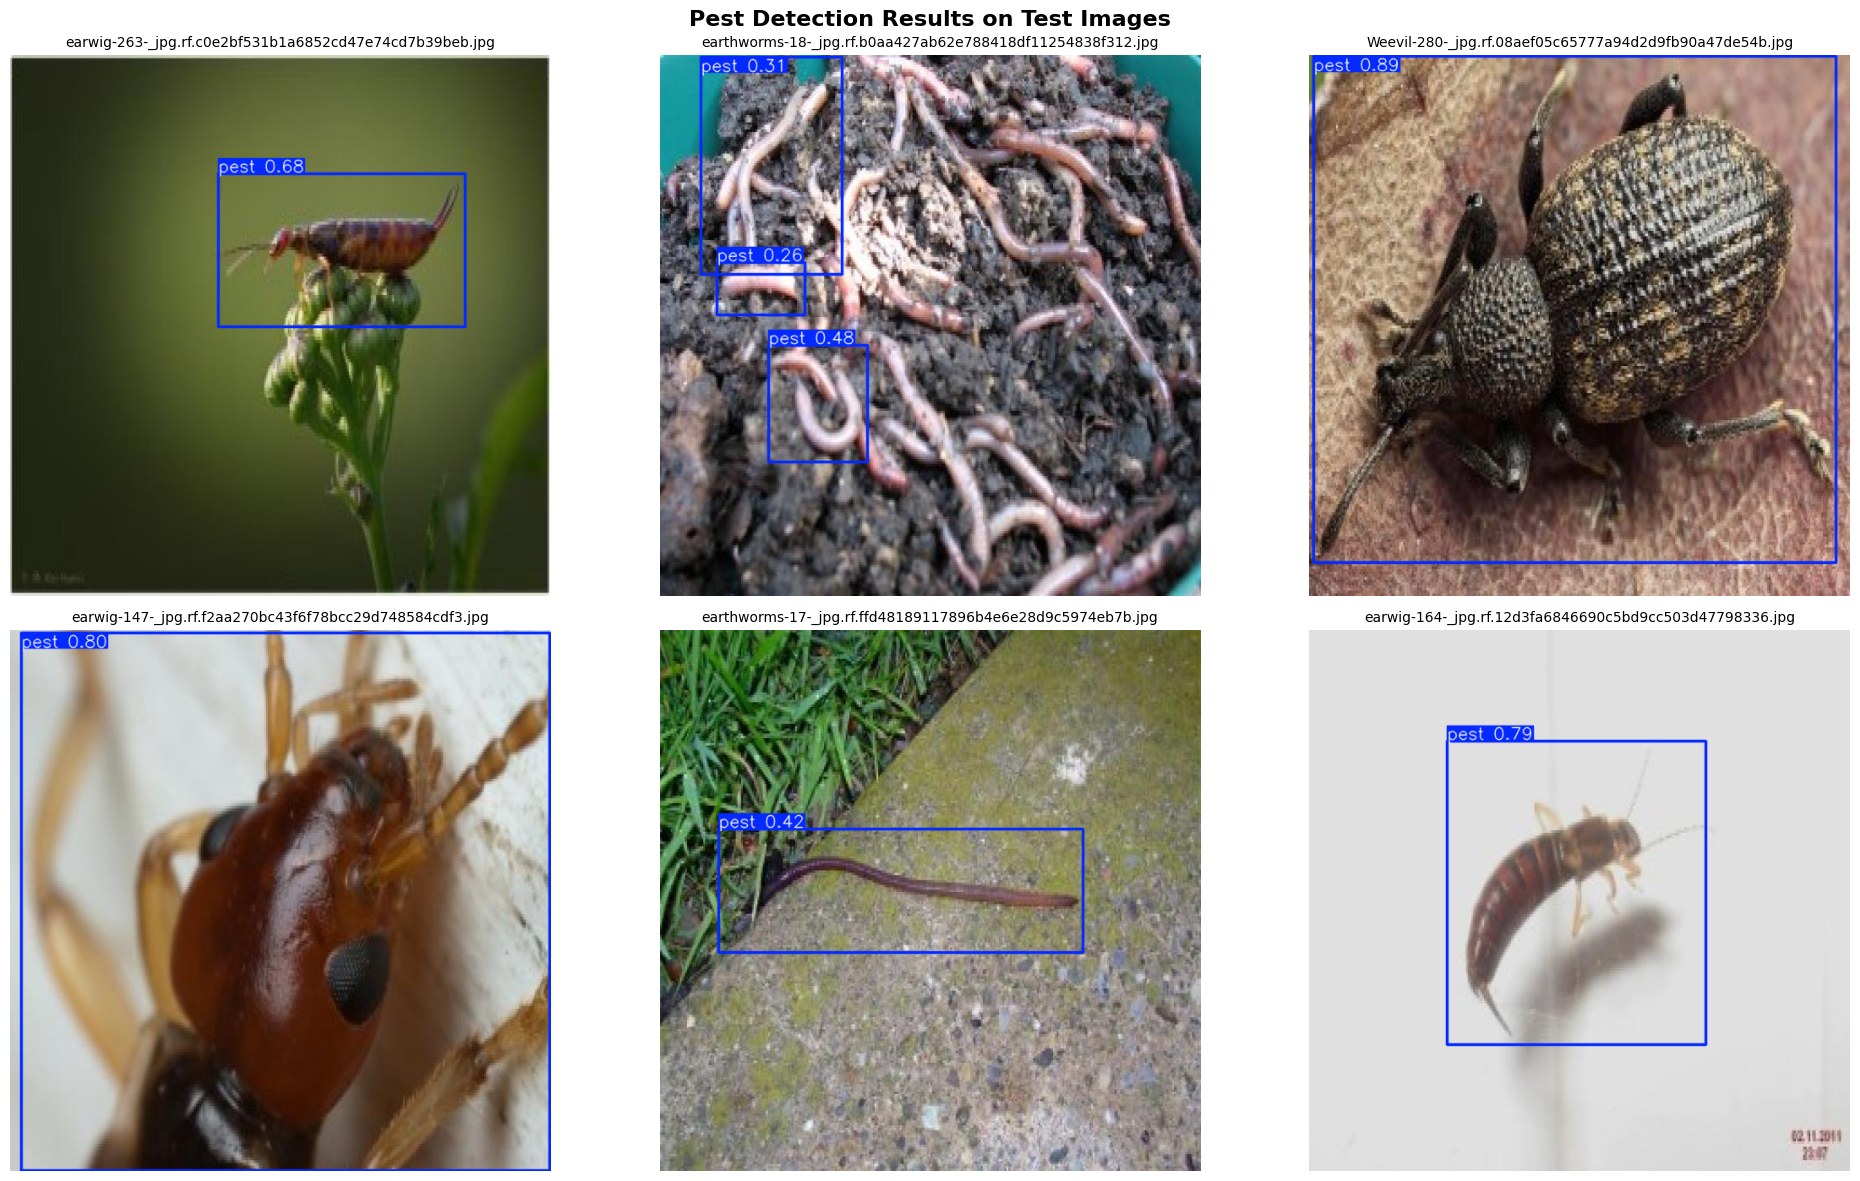

In [10]:
import cv2
import matplotlib.pyplot as plt
import random

# Run inference on test images
test_img_dir = os.path.join(dataset_root, "test", "images")
if os.path.exists(test_img_dir):
    test_images = [f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected = random.sample(test_images, min(6, len(test_images)))
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()
    
    for ax, img_name in zip(axes, selected):
        img_path = os.path.join(test_img_dir, img_name)
        
        # Run prediction
        pred_results = best_model.predict(img_path, conf=0.25, verbose=False)
        
        # Get the annotated image
        annotated = pred_results[0].plot()
        annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        
        ax.imshow(annotated)
        ax.set_title(img_name, fontsize=10)
        ax.axis("off")
    
    plt.suptitle("Pest Detection Results on Test Images", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print(f"Test images directory not found: {test_img_dir}")

## 7. Model Export
Once training is complete, the PyTorch checkpoint (`best.pt`) is optimized for training. To deploy this model into production (e.g. mobile applications, edge devices, or web servers), exporting it to formats like **ONNX** or **TensorRT** is highly recommended. ONNX files provide high compatibility and runtime performance optimization.

In [11]:
# Export the best weights to ONNX format
onnx_file = best_model.export(format="onnx")

print(f"\nSUCCESS: Model successfully exported to ONNX format!")
print(f"You can find your production-ready model here: {onnx_file}")

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/detect/yolo11_pest_detector/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 645ms
Prepared 2 packages in 808ms
Installed 2 packages in 16ms
 + onnxruntime==1.28.0
 + onnxslim==0.1.95

requirements: AutoUpdate success ✅ 1.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.95...
ONNX: export success ✅ 3.5s, saved as '/kaggle/working/runs/detect/yolo11_pest_detector/weights/b